In [70]:
# Setting enviroment variable
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

# Access the variables
gemini_api_key = os.getenv("GOOGLE_API_KEY")

In [71]:
from typing import Annotated,Sequence, TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages # helper function to add messages to the state


class AgentState(TypedDict):
    """The state of the agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    number_of_steps: int

In [72]:
from langchain_core.tools import tool
from geopy.geocoders import Nominatim
from pydantic import BaseModel, Field
import requests

geolocator = Nominatim(user_agent="weather-app")

class SearchInput(BaseModel):
    location:str = Field(description="The city and state, e.g., San Francisco")
    date:str = Field(description="the forecasting date for when to get the weather format (yyyy-mm-dd)")

@tool("get_weather_forecast", args_schema=SearchInput, return_direct=True)
def get_weather_forecast(location: str, date: str):
    """Retrieves the weather using Open-Meteo API for a given location (city) and a date (yyyy-mm-dd). Returns a list dictionary with the time and temperature."""
    print("loc1:",location);
    location = geolocator.geocode(location)
    print("loc2:",location);
    if location:
        try:
            response = requests.get(f"https://api.open-meteo.com/v1/forecast?latitude={location.latitude}&longitude={location.longitude}&hourly=temperature_2m&start_date={date}&end_date={date}")
            data = response.json()
            return {time: temp for time, temp in zip(data["hourly"]["time"], data["hourly"]["temperature_2m"])}
        except Exception as e:
            return {"error": str(e)}
    else:
        return {"error": "Location not found"}

tools = [get_weather_forecast]

In [73]:
from datetime import datetime
from langchain_google_genai import ChatGoogleGenerativeAI

# Create LLM class
llm = ChatGoogleGenerativeAI(
    model= "gemini-2.5-pro",
    temperature=1.0,
    max_retries=2,
    google_api_key=gemini_api_key,
    verbose=True,
)

# Bind tools to the model
model = llm.bind_tools([get_weather_forecast])

# Test the model with tools
res=model.invoke(f"What is the weather in Berlin on {datetime.today()}?")

print(res)

content='I can only retrieve the weather for a specific date, not for a specific time. Would you like me to get the weather for the entire day of November 12, 2025?' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []} id='lc_run--6c83aeea-ae85-4510-b6f9-97ebadd94980-0' usage_metadata={'input_tokens': 145, 'output_tokens': 41, 'total_tokens': 534, 'input_token_details': {'cache_read': 0}}


In [74]:
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableConfig

tools_by_name = {tool.name: tool for tool in tools}

# Define our tool node
def call_tool(state: AgentState):
    outputs = []
    # Iterate over the tool calls in the last message
    for tool_call in state["messages"][-1].tool_calls:
        # Get the tool by name
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=tool_result,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}

def call_model(
    state: AgentState,
    config: RunnableConfig,
):
    # Invoke the model with the system prompt and the messages
    response = model.invoke(state["messages"], config)
    # We return a list, because this will get added to the existing messages state using the add_messages reducer
    return {"messages": [response]}


# Define the conditional edge that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    # If the last message is not a tool call, then we finish
    if not messages[-1].tool_calls:
        return "end"
    # default to continue
    return "continue"

In [75]:
from langgraph.graph import StateGraph, END

# Define a new graph with our state
workflow = StateGraph(AgentState)

# 1. Add our nodes 
workflow.add_node("llm", call_model)
workflow.add_node("tools",  call_tool)
# 2. Set the entrypoint as `agent`, this is the first node called
workflow.set_entry_point("llm")
# 3. Add a conditional edge after the `llm` node is called.
workflow.add_conditional_edges(
    # Edge is used after the `llm` node is called.
    "llm",
    # The function that will determine which node is called next.
    should_continue,
    # Mapping for where to go next, keys are strings from the function return, and the values are other nodes.
    # END is a special node marking that the graph is finish.
    {
        # If `tools`, then we call the tool node.
        "continue": "tools",
        # Otherwise we finish.
        "end": END,
    },
)
# 4. Add a normal edge after `tools` is called, `llm` node is called next.
workflow.add_edge("tools", "llm")

# Now we can compile and visualize our graph
graph = workflow.compile()

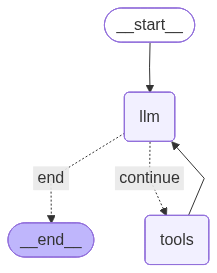

In [76]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [77]:
from datetime import datetime
# Create our initial message dictionary
inputs = {"messages": [("user", f"What is the weather in Berlin on {datetime.today()}?")]}

# call our graph with streaming to see the steps
for state in graph.stream(inputs, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()

================================ Human Message =================================

What is the weather in Berlin on 2025-11-12 00:37:30.581179?
================================== Ai Message ==================================
Tool Calls:
  get_weather_forecast (29703e99-9965-4ad8-b3e1-544a3023b3b3)
 Call ID: 29703e99-9965-4ad8-b3e1-544a3023b3b3
  Args:
    date: 2025-11-12
    location: Berlin
loc1: Berlin
loc2: Berlin, Deutschland
================================= Tool Message =================================
Name: get_weather_forecast

{'2025-11-12T00:00': 6.6, '2025-11-12T01:00': 5.9, '2025-11-12T02:00': 5.5, '2025-11-12T03:00': 5.3, '2025-11-12T04:00': 5.3, '2025-11-12T05:00': 5.2, '2025-11-12T06:00': 5.0, '2025-11-12T07:00': 5.0, '2025-11-12T08:00': 5.4, '2025-11-12T09:00': 6.4, '2025-11-12T10:00': 8.0, '2025-11-12T11:00': 9.7, '2025-11-12T12:00': 11.1, '2025-11-12T13:00': 11.8, '2025-11-12T14:00': 11.9, '2025-11-12T15:00': 11.5, '2025-11-12T16:00': 10.8, '2025-11-12T17:00': 10.0, 

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 2
Please retry in 20.458367738s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-pro"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 2
}
, retry_delay {
  seconds

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 2
Please retry in 18.371800524s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-pro"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 2
}
, retry_delay {
  seconds: 18
}
]

In [ ]:
state["messages"].append(("user", "Would it be in Munich warmer?"))

for state in graph.stream(state, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()

================================ Human Message =================================

Would it be in Munich warmer?
================================== Ai Message ==================================
Tool Calls:
  get_weather_forecast (ac8f10a2-29b0-4612-babd-5e3c247aff63)
 Call ID: ac8f10a2-29b0-4612-babd-5e3c247aff63
  Args:
    date: 2025-11-08
    location: Munich
loc1: Munich
loc2: München, Bayern, Deutschland
================================= Tool Message =================================
Name: get_weather_forecast

{'2025-11-08T00:00': 1.1, '2025-11-08T01:00': 1.0, '2025-11-08T02:00': 0.9, '2025-11-08T03:00': 0.9, '2025-11-08T04:00': 1.0, '2025-11-08T05:00': 0.8, '2025-11-08T06:00': 0.8, '2025-11-08T07:00': 1.0, '2025-11-08T08:00': 1.1, '2025-11-08T09:00': 1.4, '2025-11-08T10:00': 2.0, '2025-11-08T11:00': 2.3, '2025-11-08T12:00': 3.3, '2025-11-08T13:00': 3.9, '2025-11-08T14:00': 4.4, '2025-11-08T15:00': 5.0, '2025-11-08T16:00': 5.4, '2025-11-08T17:00': 5.7, '2025-11-08T18:00': 5.7, '20